## supervised machine learning

here we will explore diffrent machine learning models for the `seed` dataset 

we will begin by downloading the dataset , 

In [1]:
# imports 
import os 
from pathlib import Path 
import urllib.request as request
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn 
import numpy as np
%matplotlib inline

**dowload the data**

In [2]:
# dowload the data 
!curl https://archive.ics.uci.edu/static/public/236/seeds.zip -o test.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  9432    0  9432    0     0   4538      0 --:--:--  0:00:02 --:--:--  4538


**unzip the zip folder and remove teh zip folder and then move the `.txt` file to a csv file**

In [3]:
!unzip -o test.zip
!rm -f *.zip
!mv -f seeds_dataset.txt seeds_dataset.tsv

Archive:  test.zip
 extracting: seeds_dataset.txt       


**now import the csv file**

In [4]:

cols = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
    "label"
]

df = pd.read_csv(
    "seeds_dataset.tsv",
    sep=r"\s+",
    header=None,
    names=cols
)

df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,label
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [5]:
df.size

1680

my data size is `1680` i willuse `20%` of this data as test data and then train model on the remaining data, first i will have to do stratifed sampling to make  sure the test set is representative of the data we have 

In [6]:
df['label'].value_counts()

label
1    70
2    70
3    70
Name: count, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split


In [8]:
train_df, test_df = train_test_split(df,stratify=df['label'],test_size=0.2)

In [9]:
df['label'].value_counts() / df.size

label
1    0.041667
2    0.041667
3    0.041667
Name: count, dtype: float64

In [10]:
test_df['label'].value_counts() / test_df.size

label
2    0.041667
1    0.041667
3    0.041667
Name: count, dtype: float64

In [11]:
train_df['label'].value_counts() / train_df.size

label
2    0.041667
3    0.041667
1    0.041667
Name: count, dtype: float64

create a mapping from id to label and from label to id

In [12]:
"label — class target: 1, 2, or 3, which correspond to the wheat varieties Kama, Rosa, and Canadian." 
label_to_id = {"Kama":1,"Rosa":2,"Canadian":3} 
id_to_label = {v:k for k, v in label_to_id.items()}

we will first prototype a few machine learnig model and then select about 4 to 5 promising model and then aftger that fine tune them :), 
first we will create a pre processing piplinea , for examp;le standardize the data, fill in null values, 
first beforfe doing that we will draw histogram of the features to see how they look like and if they are distrubuted well for the model to perform okay \
actually after applying the log transformation performance didnt improve i will leave it but i will add two new features for the feature which has two modes 

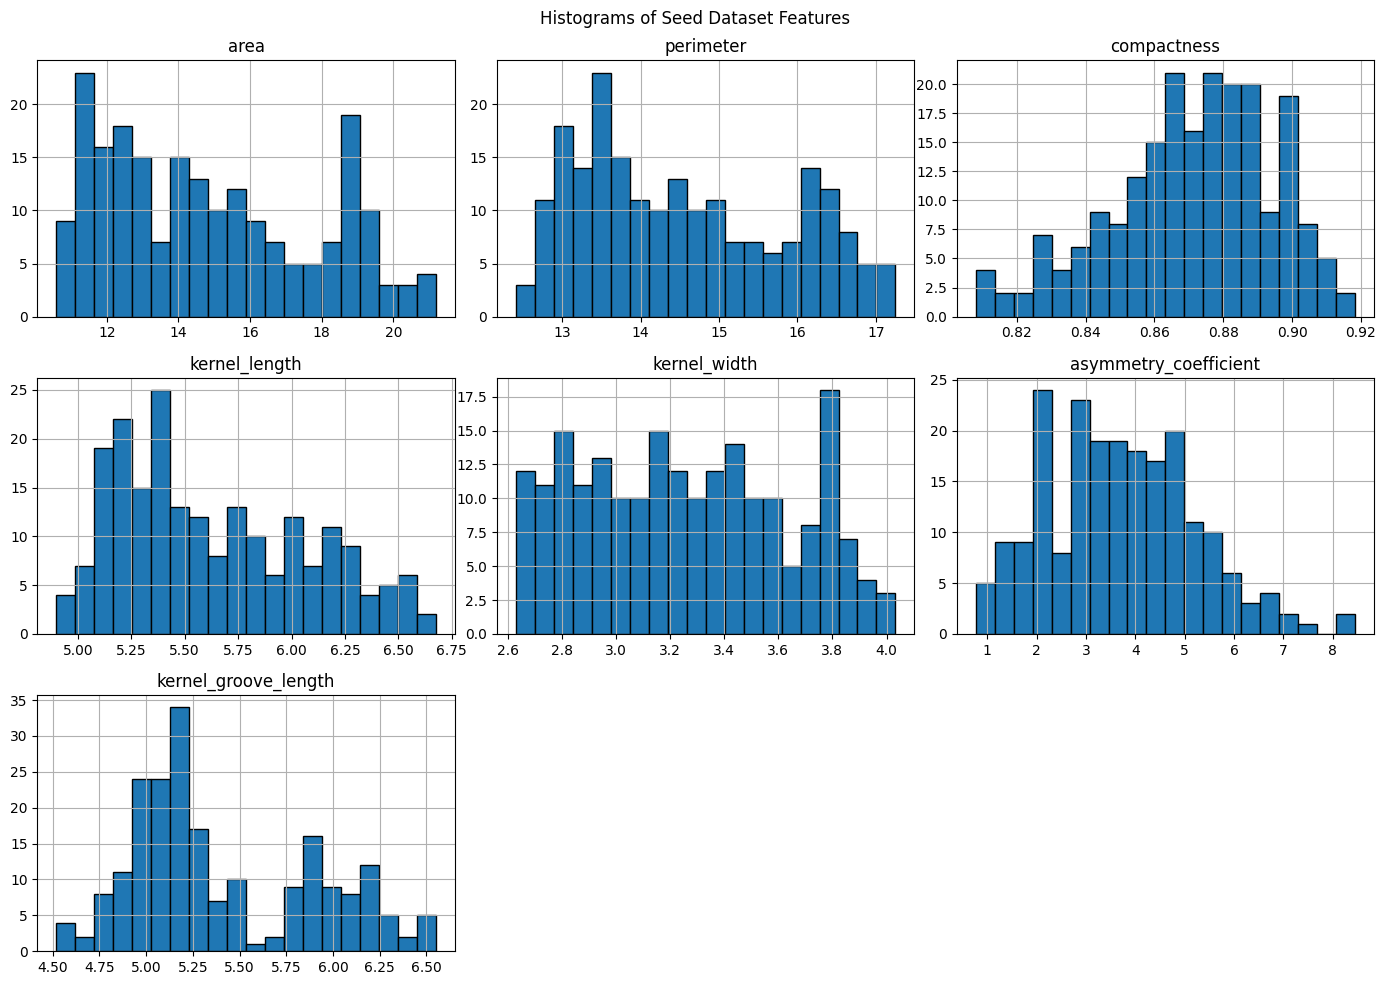

In [13]:
#all columns except the target
features = df.drop(columns="label")

features.hist(bins=20, figsize=(14, 10), edgecolor="black")
plt.suptitle("Histograms of Seed Dataset Features")
plt.tight_layout()
plt.show()

based on the histogram we can see that some featuers are skwed we will need to apply some preporcessing to them like fore example taking log of the features, also in the features `kernel-groove-lenght` is a special case because it looks like it has two modes, for this we can create two new features based on the distance from each mode using something like `rbf-kernel` 

Text(0.5, 1.0, 'label distrubtioin')

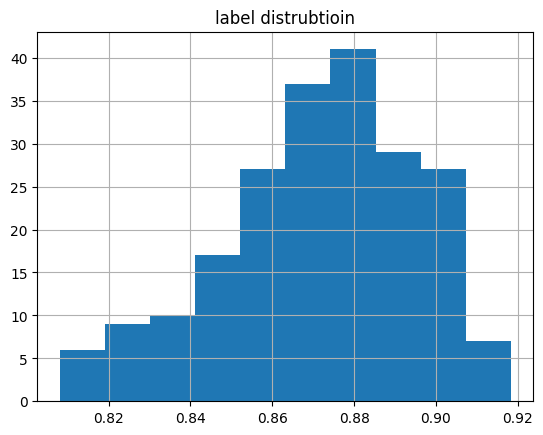

In [14]:
df['compactness'].hist()
plt.title("label distrubtioin")



we can see the labels are well distributed, no need for preprocessing :) 

<Axes: >

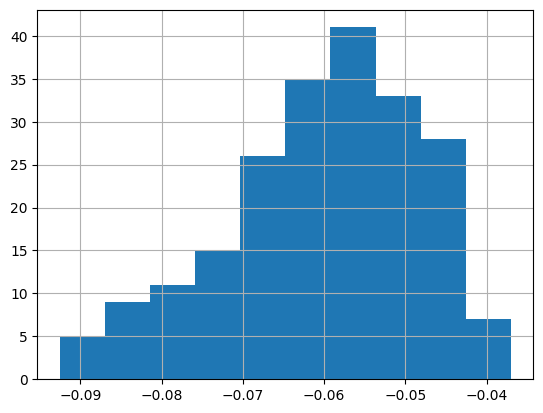

In [15]:
np.log10(df['compactness']).hist()

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [17]:
train_df['kernel_groove_length'].mode()

0    5.001
1    5.132
Name: kernel_groove_length, dtype: float64

In [18]:
m1 = 4.825
m2 = 5.001

gamma = 50  
def rbf_two_modes(x):
    """
    x is expected to be shape (n_samples, 1)
    returns shape (n_samples, 2)
    """
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    f1 = np.exp(-gamma * (x - m1) ** 2)
    f2 = np.exp(-gamma * (x - m2) ** 2)
    return np.hstack([f1, f2])

rbf_transformer = FunctionTransformer(rbf_two_modes, validate=False)

In [19]:
preprocessing_pipeline  = make_pipeline( 
    SimpleImputer(strategy='mean'),
    StandardScaler())

In [20]:
feature_cols = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
]

preprocess = ColumnTransformer(
    transformers=[
        ("rbf_groove", rbf_transformer, ["kernel_groove_length"]),
        ("sclaer_num", SimpleImputer(strategy='mean'), [c for c in feature_cols if c != "kernel_groove_length"]),
        ("num",StandardScaler(), [c for c in feature_cols if c != "kernel_groove_length"]),
    ],
    remainder="drop"
)

In [21]:
preprocess.fit_transform(train_df)

array([[ 2.93122246e-49,  1.66559686e-38,  2.00300000e+01, ...,
         1.99626499e+00,  1.63718313e+00, -4.83617215e-01],
       [ 5.88831681e-02,  8.25141824e-01,  1.08000000e+01, ...,
        -1.48136216e+00, -1.18520642e+00,  6.35243752e-01],
       [ 8.80817920e-08,  4.25689649e-04,  1.30700000e+01, ...,
        -3.52053343e-01, -7.13900060e-01,  9.82679526e-01],
       ...,
       [ 2.12502824e-01,  1.00000000e+00,  1.23700000e+01, ...,
        -9.68458154e-01, -8.06526744e-01,  7.64675729e-02],
       [ 2.12502824e-01,  1.00000000e+00,  1.42800000e+01, ...,
        -5.24554689e-01,  1.14291469e-01,  1.88627426e+00],
       [ 8.98274288e-03,  4.23988053e-01,  1.40100000e+01, ...,
        -3.69508836e-02, -2.67112525e-01, -1.03715896e+00]],
      shape=(168, 14))

lets  start to do some prototyping to see some promising model before we fine tune them 

In [22]:
from sklearn.svm import SVC

In [26]:
svc_pipline = make_pipeline(
    preprocess,
    SVC(kernel='rbf',C=1.0))

In [28]:
label = train_df.label

In [29]:
label

119    2
175    3
140    3
32     1
168    3
      ..
132    2
75     2
204    3
39     1
67     1
Name: label, Length: 168, dtype: int64

In [30]:
from sklearn.model_selection import cross_val_score 

am going to use accuracy for measuring score because the target classes are balanced, 


In [31]:
accuracy = cross_val_score(svc_pipline,train_df,label) 

In [32]:
accuracy

array([0.97058824, 0.85294118, 0.91176471, 0.87878788, 0.81818182])

In [36]:
accuracy.mean().item()

0.8864527629233512

for the scv  we get the scores as `array([0.97058824, 0.85294118, 0.91176471, 0.87878788, 0.81818182])` that is on average about `0.884` , that a good value let see how others will perform 
